In [2]:
import pandas as pd
import seaborn as sns

In [3]:
# products_cat.csv
url = "https://drive.google.com/file/d/142JPuGLbHudihj6fkgn6bjvYD14gMZ-I/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cat = pd.read_csv(path)

# orders_qu.csv
url = "https://drive.google.com/file/d/18Q7470TZmdwp_iYY56xtoCRGBHRSXkOp/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_qu = pd.read_csv(path)

# orderlines_qu.csv
url = "https://drive.google.com/file/d/1e1TLfLaYrD4U9VmgvtgQLSNesMyhFlk1/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qu = pd.read_csv(path)

# brands.csv
url = "https://drive.google.com/file/d/1m1ThDDIYRTTii-rqM5SEQjJ8McidJskD/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands_df = pd.read_csv(path)

Creating copies, changing _qu to _da

In [4]:
orders_da = orders_qu.copy()
orderlines_da = orderlines_qu.copy()
products_da = products_cat.copy()
brands_da = brands_df.copy()

# Creating the tables

Adding brands to products

In [5]:
products_da["short"] = products_da["sku"].str[:3]
products_da = products_da.merge(brands_da, on="short", how="inner")
products_da = products_da.rename(columns={"long": "brand"})

In [6]:
#drop the short column
products_da = products_da.drop(columns="short")

Define Pandas display format

In [7]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)
pd.set_option("display.max_rows", 1000)

Discount table

In [8]:
# Merge orderlines_da and products_da to be able to figure out the discount
orderlines_products_da = orderlines_da.merge(products_da, on="sku",how="inner")

In [9]:
# The table is too big and in the end should include the discout.
# Dropping anything unneccesary for this: id, product_id, sku, desc, in_stock, type
orderlines_products_da = orderlines_products_da.drop(columns=["id", "product_id", "desc", "in_stock", "type"])

In [10]:
# Renaming columns: id_order = order_id, product_quantity = qty
orderlines_products_da = orderlines_products_da.rename(columns={"id_order": "order_id", "product_quantity": "qty"})

In [11]:
# Creating a new column for discounts, where discounts = price - unit_price
orderlines_products_da["discount"] = orderlines_products_da["price"] - orderlines_products_da["unit_price"]

orderlines_products_da.loc[orderlines_products_da["discount"] < 0, "discount"] = 0

In [12]:
orderlines_products_da

,order_id,qty,sku,unit_price,date,name,price,category,condition,brand,discount
0,299545,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,60.99,other,new,OWC,13.50
1,299546,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,22.95,stands_mounts,new,iOttie,3.96
2,295347,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,89.00,charger_adapter,new,Apple,16.81
3,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,76.99,storage,open_box,Crucial,16.09
4,299561,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,299.99,other,new,Pebble,157.50
...,...,...,...,...,...,...,...,...,...,...,...
53190,527035,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,25.00,charger_adapter,new,Apple,15.01
53191,527070,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,25.00,charger_adapter,new,Apple,15.01
53192,527074,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,25.00,charger_adapter,new,Apple,15.01
53193,527096,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,25.00,charger_adapter,new,Apple,15.01


In [13]:
# check biggest and smallest discount
#orderlines_products_da.nlargest(15, columns="discount")
orderlines_products_da.nsmallest(15, columns="discount")

,order_id,qty,sku,unit_price,date,name,price,category,condition,brand,discount
44,299776,1,BNQ0053,398.99,2017-01-01 16:34:28,"PD2700Q Monitor Benq 27 ""QHD 10bit HDMI pivotable",337.00,monitor,new,BenQ,0.00
55,299829,1,LAC0171,275.49,2017-01-01 17:50:48,LaCie Porsche Design Desktop Drive 8TB USB 3.0...,249.99,storage,new,LaCie,0.00
75,299909,1,LAC0159,176.69,2017-01-01 19:50:09,LaCie Porsche Design Desktop Drive 5TB USB 3.0...,174.99,storage,new,LaCie,0.00
82,299947,1,APP1482,549.00,2017-01-01 20:32:33,Apple iPhone 64GB Silver,549.00,smartphone,new,Apple,0.00
84,299959,2,IFX0079,5.99,2017-01-01 20:47:34,iFixit part adhesive strips Battery iPhone 6 / 6S,5.95,repair_parts,new,iFixit,0.00
86,299968,1,ADN0019,7.99,2017-01-01 20:53:05,Adonit Jot Pro Disc Replacement Flip mini and ...,7.99,input_devices,new,Adonit,0.00
102,300035,1,APP1641,909.00,2017-01-01 22:05:04,Apple iPhone 7 Plus 32GB Silver,779.00,smartphone,new,Apple,0.00
107,300046,1,APP0482,35.00,2017-01-01 22:18:34,Adapter Apple Lightning to SD Card Reader,35.00,charger_adapter,new,Apple,0.00
113,299466,2,APP1648,879.00,2017-01-01 22:38:40,Apple iPhone 7 128GB Black,749.00,smartphone,new,Apple,0.00
118,299404,1,KIN0156,37.99,2017-01-01 22:55:53,Mac memory Kingston 4GB SO-DIMM DDR3åÊ1333MhzåÊ,35.53,memory,new,Kingston,0.00


# First analysis and questions answered

What is the time period that the dataset covers?

In [14]:
# convert date from string to datetime
orderlines_products_da["date"] = pd.to_datetime(orderlines_products_da["date"])

In [15]:
# get the min, max and timespan of the dates
date_start = orderlines_products_da["date"].min()
date_end = orderlines_products_da["date"].max()
date_timespan = orderlines_products_da["date"].max() - orderlines_products_da["date"].min()

print(f"The data set covers a time period from {date_start} to {date_end}, which covers a total of {date_timespan}")

The data set covers a time period from 2017-01-01 01:46:16 to 2018-03-14 11:58:13, which covers a total of 437 days 10:11:57


What is the overall revenue for that time?

In [16]:
# calculating the total revenue by unit_price * qty and getting the .sum() of it
orderlines_products_da["unit_price_total"] = orderlines_products_da["unit_price"] * orderlines_products_da["qty"]
orderlines_products_da["unit_price_total"].sum()

print(f"The overall revenue of that time is {round(orderlines_products_da["unit_price_total"].sum(), 2)}")

The overall revenue of that time is 7811609.29


In [17]:
orderlines_da

,id,id_order,product_id,product_quantity,sku,unit_price,date
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50
...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35


Are there seasonal patterns in the evolution of sales?

/tmp/ipykernel_602/3515834431.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (orderlines_products_da.resample("M", on="date")["unit_price_total"].sum().plot(figsize=(10,6)));


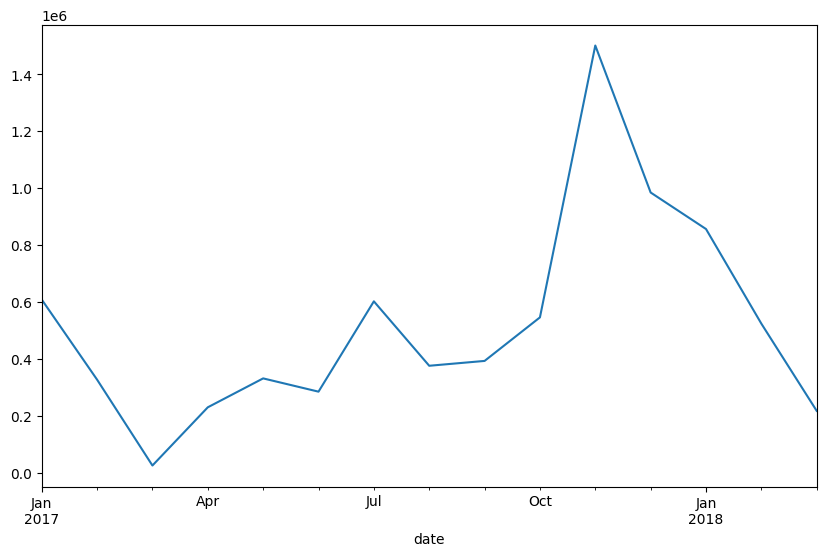

In [18]:
(orderlines_products_da.resample("M", on="date")["unit_price_total"].sum().plot(figsize=(10,6)));

What are the most sold products?

In [19]:
# Grouping by sku and name and then aggregating by the sum of the qty to find out the most sold products
orderlines_products_da.groupby(["sku", "name"])["qty"].sum().sort_values(ascending= False).head(10)

,,qty
sku,name,
APP1190,IPhone AppleCare Protection Plan,955
APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),820
APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,537
APP0927,EarPods Apple Headphones with Remote and Mic (OEM),489
WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",476
SAM0074,Samsung 850 EVO SSD Disk 500GB,329
CRU0051,Crucial MX300 525GB SSD Disk,328
APP2446,Apple iPhone 6 32GB Space Gray,270
NTE0013,"AdaptaDrive NewerTech adapter 2.5 ""to 3.5"" SATA",252


What are the products that generate the most revenue?

In [20]:
# Grouping by sku and name then aggregating by the sum of the total unit price to find out which products generate the most revenue
orderlines_products_da.groupby(["sku", "name"])["unit_price_total"].sum().sort_values(ascending=False).head(10)

,,unit_price_total
sku,name,
LGE0044,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",135375.83
APP2446,Apple iPhone 6 32GB Space Gray,104560.64
APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,86473.26
APP2477,Apple iPhone 64GB Space Gray 8,85301.93
APP1970,Apple iPhone 32GB Space Gray,80715.76
APP2072,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM | 128GB SSD",74964.06
APP2485,Apple iPhone 8 Plus 64GB Gold,70721.79
WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",65589.96
APP2483,Apple iPhone 8 Plus 64GB Space Gray,60090.08


# Category Analysis

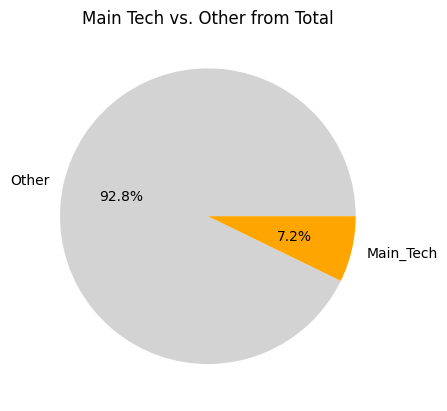

In [21]:
main_tech_categories = [
    "apple_watch",
    "ipods",
    "smartphone",
    "desktop",
    "laptop",
    "ipad"
]

orderlines_products_da["tech_group"] = orderlines_products_da["category"].isin(main_tech_categories).map({
    True: "Main_Tech",
    False: "Other"
})

orderlines_products_da["tech_group"].value_counts().plot.pie(
    autopct="%1.1f%%",
    ylabel="",
    colors=["lightgrey", "orange"],
    title="Main Tech vs. Other from Total"
);

# Discounts


In [41]:
# Average Discount
avg_discount = orderlines_products_da["discount"].mean()

print(f"the average discount is {round(avg_discount, 2)}€")

the average discount is 26.63€


In [45]:
# Discount %
orderlines_products_da["discount_pct"] = (orderlines_products_da["discount"] / orderlines_products_da["price"] * 100)

# Average Discount %
avg_discount_pct = orderlines_products_da["discount_pct"].mean()

print(f"the average discount in % is {round(avg_discount_pct, 1)}%")

the average discount in % is 21.6%


In [46]:
# below or above average
orderlines_products_da["discount_group"] = "Average"

orderlines_products_da.loc[orderlines_products_da["discount_pct"] < avg_discount_pct, "discount_group"] = "Below average"

orderlines_products_da.loc[orderlines_products_da["discount_pct"] > avg_discount_pct, "discount_group"] = "Above average"

# Distribution
orderlines_products_da["discount_group"].value_counts()

,count
discount_group,
Below average,32399
Above average,20796


<Axes: xlabel='discount_group', ylabel='count'>

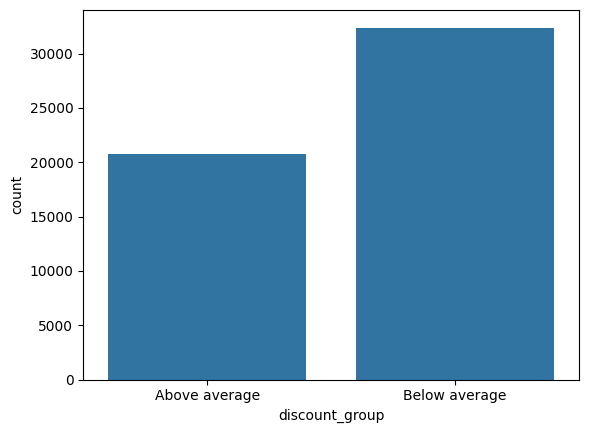

In [25]:
# How many discounts are below and how many above average?
sns.countplot(
    data=orderlines_products_da,
    x="discount_group"
)

<Axes: xlabel='condition', ylabel='count'>

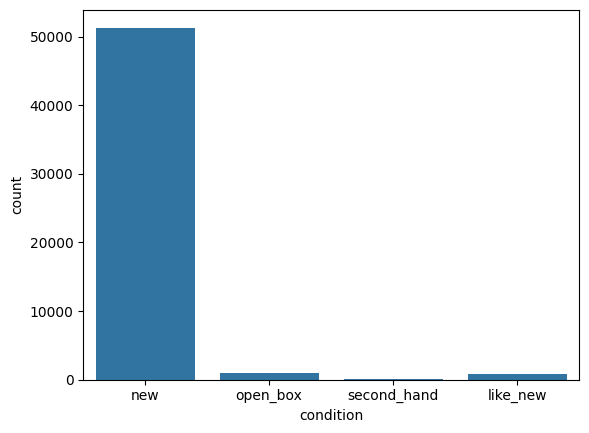

In [26]:
# How many products have been sold across the different conditions
sns.countplot(
    data=orderlines_products_da,
    x="condition"
)

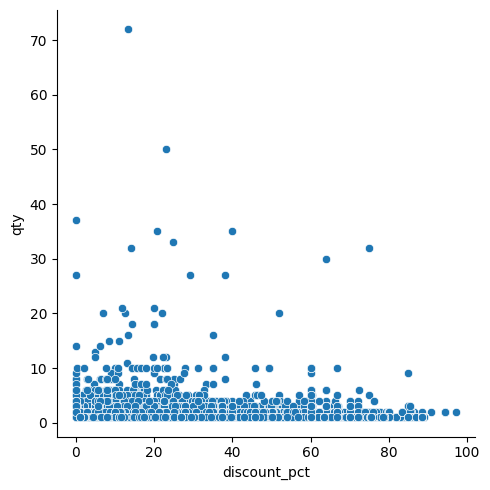

In [27]:
# Discount Scatter Plot
g = sns.relplot(
    data=orderlines_products_da,
    x="discount_pct",
    y="qty"
    )

# Average Discount vs Monthly Discount

/tmp/ipykernel_602/3160505339.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


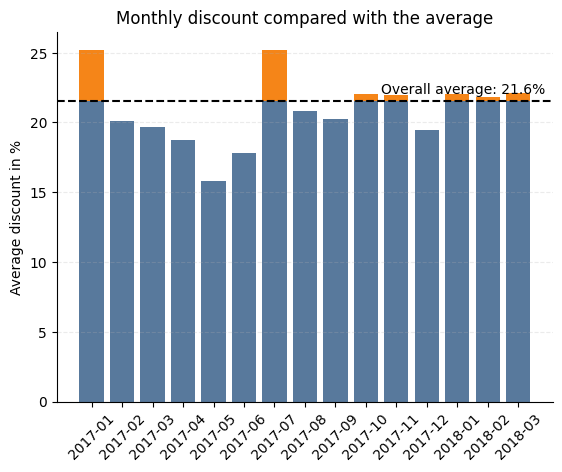

In [28]:
# Create month column
orderlines_products_da["month"] = orderlines_products_da["date"].dt.to_period("M")

# Average discount per month
monthly_discount = (
    orderlines_products_da
    .groupby("month")["discount_pct"]
    .mean()
    .reset_index()
)

# Split the bars at the average
monthly_discount["below_average"] = monthly_discount["discount_pct"].where(
    monthly_discount["discount_pct"] < avg_discount_pct,
    avg_discount_pct
)

monthly_discount["above_average"] = monthly_discount["discount_pct"] - avg_discount_pct
monthly_discount["above_average"] = monthly_discount["above_average"].where(
    monthly_discount["above_average"] > 0,
    0
)

# Plot
ax = sns.barplot(
    data=monthly_discount,
    x="month",
    y="below_average",
    color="#4C78A8"
)

# Add orange part
for i in range(len(monthly_discount)):
    if monthly_discount.loc[i, "above_average"] > 0:
        ax.bar(
            i,
            monthly_discount.loc[i, "above_average"],
            bottom=avg_discount_pct,
            color="#F58518"
        )

# Average line
ax.axhline(avg_discount_pct, color="black", linestyle="--")

# Average label
ax.text(
    len(monthly_discount) - 0.1,
    avg_discount_pct + 0.5,
    f"Overall average: {avg_discount_pct:.1f}%",
    ha="right"
)

# Labels
ax.set(
    xlabel=None,
    ylabel="Average discount in %",
    title="Monthly discount compared with the average"
)

# Month labels
ax.set_xticklabels(
    monthly_discount["month"].dt.strftime("%Y-%m"),
    rotation=45
)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.25)

sns.despine()

# Monthly Discount count vs Average

/tmp/ipykernel_602/317938126.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


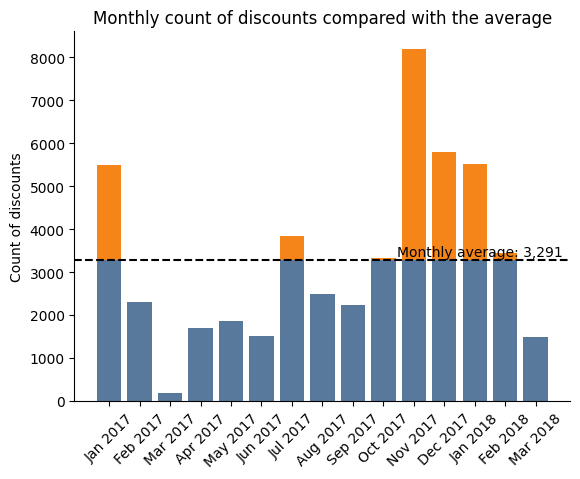

In [29]:
# Count discounted products per month
monthly_discount = (orderlines_products_da[orderlines_products_da["discount"] > 0].groupby("month").count()["order_id"].reset_index())

monthly_discount.columns = ["month", "discounts"]

# Average number of discounts per month
average = monthly_discount["discounts"].mean()

# Split the bars at the average
monthly_discount["below_average"] = monthly_discount["discounts"].where(monthly_discount["discounts"] < average, average)

monthly_discount["above_average"] = monthly_discount["discounts"] - average
monthly_discount["above_average"] = monthly_discount["above_average"].where(monthly_discount["above_average"] > 0,0)

# Plot
ax = sns.barplot(
    data=monthly_discount,
    x="month",
    y="below_average",
    color="#4C78A8"
)

# Add orange part
for i in range(len(monthly_discount)):
    if monthly_discount.loc[i, "above_average"] > 0:
        ax.bar(
            i,
            monthly_discount.loc[i, "above_average"],
            bottom=average,
            color="#F58518"
        )

# Average line
ax.axhline(average, color="black", linestyle="--")

ax.text(
    len(monthly_discount) - 0.1,
    average,
    f"Monthly average: {average:,.0f}",
    ha="right",
    va="bottom"
)

# Labels
ax.set(
    xlabel=None,
    ylabel="Count of discounts",
    title="Monthly count of discounts compared with the average"
)

ax.set_xticklabels(
    monthly_discount["month"].dt.strftime("%b %Y"),
    rotation=45
)

sns.despine()

In [48]:
main_tech = orderlines_products_da[orderlines_products_da["tech_group"] == "Main_Tech"]

avg_discount_main_tech = main_tech["discount_pct"].mean()

print(f" the average discount  is {round(avg_discount_main_tech, 1)}%")

 the average discount  is 10.5%


In [50]:
total_main_tech = main_tech["order_id"].count()

print(f"The total amount of tech sales is {total_main_tech}")

The total amount of tech sales is 3833


In [49]:
discounted_main_tech = main_tech[main_tech["discount"] > 0]

discount_count_main_tech = discounted_main_tech["order_id"].count()

print(f"Out of all high-end tech sales {discount_count_main_tech} were discounted")

Out of all tech sales 3522 were discounted


In [52]:
discounted_percentage = discount_count_main_tech / total_main_tech * 100

print(f"Out of all high-end tech sales {round(discounted_percentage, 1)}% were discounted")

Out of all high-end tech sales 91.9% were discounted


In [35]:
# Compare average discount percentage by group
orderlines_products_da.groupby("tech_group")["discount_pct"].mean()

,discount_pct
tech_group,
Main_Tech,10.54
Other,22.43


In [36]:
# Compare amount of discounted products
orderlines_products_da[orderlines_products_da["discount"] > 0].groupby("tech_group")["order_id"].count()

,order_id
tech_group,
Main_Tech,3522
Other,45847


# Monthly Discount count vs Average by High-End Tech Group

/tmp/ipykernel_602/39931376.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


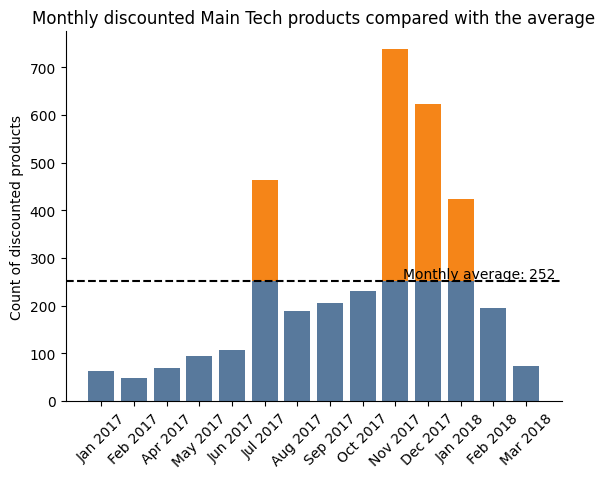

In [37]:
# Count discounted Main Tech products per month
monthly_discount = (
    orderlines_products_da[
        (orderlines_products_da["discount"] > 0) &
        (orderlines_products_da["tech_group"] == "Main_Tech")
    ]
    .groupby("month")
    .count()["order_id"]
    .reset_index()
)

monthly_discount.columns = ["month", "discounts"]

# Average number of discounts per month
average = monthly_discount["discounts"].mean()

# Split the bars at the average
monthly_discount["below_average"] = monthly_discount["discounts"].where(
    monthly_discount["discounts"] < average,
    average
)

monthly_discount["above_average"] = monthly_discount["discounts"] - average
monthly_discount["above_average"] = monthly_discount["above_average"].where(
    monthly_discount["above_average"] > 0,
    0
)

# Plot
ax = sns.barplot(
    data=monthly_discount,
    x="month",
    y="below_average",
    color="#4C78A8"
)

# Add orange part
for i in range(len(monthly_discount)):
    if monthly_discount.loc[i, "above_average"] > 0:
        ax.bar(
            i,
            monthly_discount.loc[i, "above_average"],
            bottom=average,
            color="#F58518"
        )

# Average line
ax.axhline(average, color="black", linestyle="--")

ax.text(
    len(monthly_discount) - 0.1,
    average,
    f"Monthly average: {average:,.0f}",
    ha="right",
    va="bottom"
)

# Labels
ax.set(
    xlabel=None,
    ylabel="Count of discounted products",
    title="Monthly discounted Main Tech products compared with the average"
)

ax.set_xticklabels(
    monthly_discount["month"].dt.strftime("%b %Y"),
    rotation=45
)

sns.despine();

# Average Discount vs Monthly Discount by High-End Tech Group

/tmp/ipykernel_602/3021595919.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


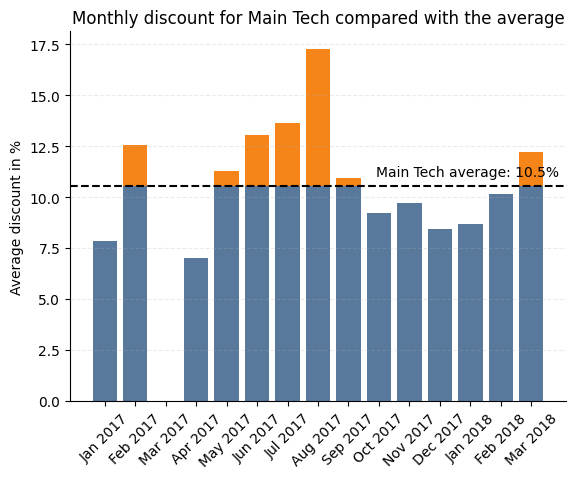

In [38]:
# Average discount for Main Tech
avg_discount_pct_main_tech = (
    orderlines_products_da[
        orderlines_products_da["tech_group"] == "Main_Tech"
    ]["discount_pct"].mean()
)

# Average discount per month
monthly_discount = (
    orderlines_products_da[
        orderlines_products_da["tech_group"] == "Main_Tech"
    ]
    .groupby("month")["discount_pct"]
    .mean()
    .reset_index()
)

# Split the bars at the Main Tech average
monthly_discount["below_average"] = monthly_discount["discount_pct"].where(
    monthly_discount["discount_pct"] < avg_discount_pct_main_tech,
    avg_discount_pct_main_tech
)

monthly_discount["above_average"] = (
    monthly_discount["discount_pct"] - avg_discount_pct_main_tech
)

monthly_discount["above_average"] = monthly_discount["above_average"].where(
    monthly_discount["above_average"] > 0,
    0
)

# Plot
ax = sns.barplot(
    data=monthly_discount,
    x="month",
    y="below_average",
    color="#4C78A8"
)

# Add orange part
for i in range(len(monthly_discount)):
    if monthly_discount.loc[i, "above_average"] > 0:
        ax.bar(
            i,
            monthly_discount.loc[i, "above_average"],
            bottom=avg_discount_pct_main_tech,
            color="#F58518"
        )

# Average line
ax.axhline(
    avg_discount_pct_main_tech,
    color="black",
    linestyle="--"
)

# Average label
ax.text(
    len(monthly_discount) - 0.1,
    avg_discount_pct_main_tech + 0.5,
    f"Main Tech average: {avg_discount_pct_main_tech:.1f}%",
    ha="right"
)

# Labels
ax.set(
    xlabel=None,
    ylabel="Average discount in %",
    title="Monthly discount for Main Tech compared with the average"
)

# Month labels
ax.set_xticklabels(
    monthly_discount["month"].dt.strftime("%b %Y"),
    rotation=45
)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.25)

sns.despine();